In [1]:
# CROSS-DATASET TEST — Load CICIDS2018
import os
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

In [2]:
# CROSS-DATASET TEST — Load CICIDS2018
import os
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

# Load all downloaded CICIDS2018 files
data_path_2018 = '../data/cicids2018/'
csv_files = [f for f in os.listdir(data_path_2018) if f.endswith('.csv')]

dfs_2018 = []
for f in sorted(csv_files):
    df_temp = pd.read_csv(os.path.join(data_path_2018, f), low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    dfs_2018.append(df_temp)
    print(f"Loaded {f}: {df_temp.shape[0]} rows")
    print(f"  Labels: {df_temp['Label'].value_counts().to_dict()}")
    print()

test_2018 = pd.concat(dfs_2018, ignore_index=True)
print(f"\nTotal: {test_2018.shape[0]} rows")
print(f"\nAll labels:")
print(test_2018['Label'].value_counts())

Loaded 02-14-2018.csv: 1048575 rows
  Labels: {'Benign': 667626, 'FTP-BruteForce': 193360, 'SSH-Bruteforce': 187589}

Loaded 02-20-2018.csv: 7948748 rows
  Labels: {'Benign': 7372557, 'DDoS attacks-LOIC-HTTP': 576191}

Loaded 03-01-2018.csv: 331125 rows
  Labels: {'Benign': 238037, 'Infilteration': 93063, 'Label': 25}


Total: 9328448 rows

All labels:
Label
Benign                    8278220
DDoS attacks-LOIC-HTTP     576191
FTP-BruteForce             193360
SSH-Bruteforce             187589
Infilteration               93063
Label                          25
Name: count, dtype: int64


In [3]:
# COLUMN MAPPING — CICIDS2018 → CICIDS2017 names
# Same features from CICFlowMeter, just abbreviated differently

column_map = {
    'Dst Port': 'Destination Port',
    'Flow Duration': 'Flow Duration',
    'Tot Fwd Pkts': 'Total Fwd Packets',
    'Tot Bwd Pkts': 'Total Backward Packets',
    'TotLen Fwd Pkts': 'Total Length of Fwd Packets',
    'TotLen Bwd Pkts': 'Total Length of Bwd Packets',
    'Fwd Pkt Len Max': 'Fwd Packet Length Max',
    'Fwd Pkt Len Min': 'Fwd Packet Length Min',
    'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
    'Fwd Pkt Len Std': 'Fwd Packet Length Std',
    'Bwd Pkt Len Max': 'Bwd Packet Length Max',
    'Bwd Pkt Len Min': 'Bwd Packet Length Min',
    'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
    'Bwd Pkt Len Std': 'Bwd Packet Length Std',
    'Flow Byts/s': 'Flow Bytes/s',
    'Flow Pkts/s': 'Flow Packets/s',
    'Flow IAT Mean': 'Flow IAT Mean',
    'Flow IAT Std': 'Flow IAT Std',
    'Flow IAT Max': 'Flow IAT Max',
    'Flow IAT Min': 'Flow IAT Min',
    'Fwd IAT Tot': 'Fwd IAT Total',
    'Fwd IAT Mean': 'Fwd IAT Mean',
    'Fwd IAT Std': 'Fwd IAT Std',
    'Fwd IAT Max': 'Fwd IAT Max',
    'Fwd IAT Min': 'Fwd IAT Min',
    'Bwd IAT Tot': 'Bwd IAT Total',
    'Bwd IAT Mean': 'Bwd IAT Mean',
    'Bwd IAT Std': 'Bwd IAT Std',
    'Bwd IAT Max': 'Bwd IAT Max',
    'Bwd IAT Min': 'Bwd IAT Min',
    'Fwd PSH Flags': 'Fwd PSH Flags',
    'Bwd PSH Flags': 'Bwd PSH Flags',
    'Fwd URG Flags': 'Fwd URG Flags',
    'Bwd URG Flags': 'Bwd URG Flags',
    'Fwd Header Len': 'Fwd Header Length',
    'Bwd Header Len': 'Bwd Header Length',
    'Fwd Pkts/s': 'Fwd Packets/s',
    'Bwd Pkts/s': 'Bwd Packets/s',
    'Pkt Len Min': 'Min Packet Length',
    'Pkt Len Max': 'Max Packet Length',
    'Pkt Len Mean': 'Packet Length Mean',
    'Pkt Len Std': 'Packet Length Std',
    'Pkt Len Var': 'Packet Length Variance',
    'FIN Flag Cnt': 'FIN Flag Count',
    'SYN Flag Cnt': 'SYN Flag Count',
    'RST Flag Cnt': 'RST Flag Count',
    'PSH Flag Cnt': 'PSH Flag Count',
    'ACK Flag Cnt': 'ACK Flag Count',
    'URG Flag Cnt': 'URG Flag Count',
    'CWE Flag Count': 'CWE Flag Count',
    'ECE Flag Cnt': 'ECE Flag Count',
    'Down/Up Ratio': 'Down/Up Ratio',
    'Pkt Size Avg': 'Average Packet Size',
    'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
    'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
    'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
    'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
    'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
    'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
    'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
    'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
    'Subflow Fwd Pkts': 'Subflow Fwd Packets',
    'Subflow Fwd Byts': 'Subflow Fwd Bytes',
    'Subflow Bwd Pkts': 'Subflow Bwd Packets',
    'Subflow Bwd Byts': 'Subflow Bwd Bytes',
    'Init Fwd Win Byts': 'Init_Win_bytes_forward',
    'Init Bwd Win Byts': 'Init_Win_bytes_backward',
    'Fwd Act Data Pkts': 'act_data_pkt_fwd',
    'Fwd Seg Size Min': 'min_seg_size_forward',
    'Active Mean': 'Active Mean',
    'Active Std': 'Active Std',
    'Active Max': 'Active Max',
    'Active Min': 'Active Min',
    'Idle Mean': 'Idle Mean',
    'Idle Std': 'Idle Std',
    'Idle Max': 'Idle Max',
    'Idle Min': 'Idle Min',
}

# Rename columns
test_2018 = test_2018.rename(columns=column_map)

# Drop Timestamp and Protocol (not in our CICIDS2017 features)
test_2018 = test_2018.drop(columns=['Timestamp', 'Protocol'], errors='ignore')

# Check if we have all 78 features
model_features = joblib.load('../models/scaler.joblib').feature_names_in_
missing = [f for f in model_features if f not in test_2018.columns]
extra = [f for f in test_2018.columns if f not in model_features and f != 'Label']

print(f"Model expects: {len(model_features)} features")
print(f"2018 has: {len(test_2018.columns) - 1} features (excluding Label)")
print(f"Missing: {missing}")
print(f"Extra: {extra}")

Model expects: 78 features
2018 has: 81 features (excluding Label)
Missing: ['Fwd Header Length.1']
Extra: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP']


In [4]:
# Fix column mismatches
test_2018 = test_2018.drop(columns=['Flow ID', 'Src IP', 'Src Port', 'Dst IP'], errors='ignore')
test_2018['Fwd Header Length.1'] = test_2018['Fwd Header Length']

# Verify
missing = [f for f in model_features if f not in test_2018.columns]
print(f"Missing features: {missing}")

# Clean
print(f"\nBefore cleaning: {test_2018.shape[0]} rows")
test_2018 = test_2018[test_2018['Label'] != 'Label']

for col in model_features:
    if col in test_2018.columns:
        test_2018[col] = pd.to_numeric(test_2018[col], errors='coerce')

test_2018 = test_2018.replace([np.inf, -np.inf], np.nan)
test_2018 = test_2018.dropna()
test_2018 = test_2018.drop_duplicates()
print(f"After cleaning: {test_2018.shape[0]} rows")

Missing features: []

Before cleaning: 9328448 rows
After cleaning: 7029943 rows


In [5]:
# Map labels to our categories
test_2018['attack_category'] = test_2018['Label'].apply(lambda x:
    'Benign' if x == 'Benign'
    else 'DoS/DDoS' if 'DDoS' in x or 'DoS' in x
    else 'Brute Force' if 'Brute' in x or 'brute' in x
    else 'Infiltration' if 'Infilt' in x
    else 'Unknown'
)
test_2018 = test_2018[test_2018['attack_category'] != 'Unknown']

# Sample — keep ALL attacks, sample benign down to 100k
attacks = test_2018[test_2018['attack_category'] != 'Benign']
benign = test_2018[test_2018['attack_category'] == 'Benign'].sample(n=100000, random_state=42)

test_2018_sampled = pd.concat([attacks, benign], ignore_index=True)

print("Sampled dataset:")
print(test_2018_sampled['attack_category'].value_counts())
print(f"\nTotal: {test_2018_sampled.shape[0]} rows")

Sampled dataset:
attack_category
DoS/DDoS        575364
Benign          100000
Brute Force      94101
Infiltration     82531
Name: count, dtype: int64

Total: 851996 rows


CROSS-DATASET: Trained on CICIDS2017 → Tested on CICIDS2018
              precision    recall  f1-score   support

      Benign       0.12      1.00      0.21    100000
 Brute Force       0.38      0.00      0.00     94101
    DoS/DDoS       0.04      0.00      0.00    575364
Infiltration       0.00      0.00      0.00     82531

   micro avg       0.12      0.12      0.12    851996
   macro avg       0.13      0.25      0.05    851996
weighted avg       0.08      0.12      0.02    851996



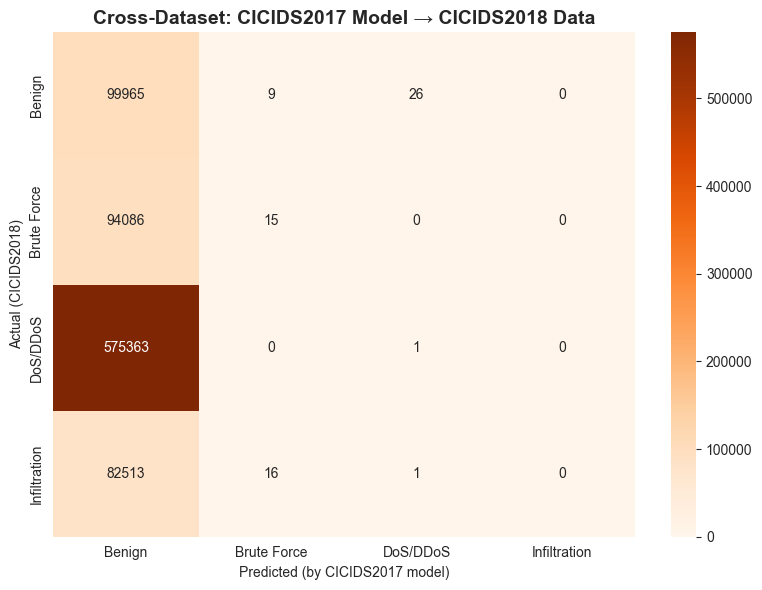


Within (CICIDS2017→2017): 99.89% acc, 0.91 macro F1
Cross  (CICIDS2017→2018): 11.73% acc, 0.053 macro F1
Performance drop: 88.16%


In [6]:
# Scale and predict
X_2018 = test_2018_sampled[model_features]
y_2018_labels = test_2018_sampled['attack_category']

target_encoder = joblib.load('../models/target_encoder.joblib')
scaler = joblib.load('../models/scaler.joblib')

y_2018_encoded = target_encoder.transform(y_2018_labels)
X_2018_scaled = scaler.transform(X_2018)

rf = joblib.load('../models/random_forest.joblib')
y_2018_pred = rf.predict(X_2018_scaled)

# Only use the classes that exist in 2018 data
present_classes = sorted(y_2018_labels.unique())
present_indices = [list(target_encoder.classes_).index(c) for c in present_classes]

print("=" * 60)
print("CROSS-DATASET: Trained on CICIDS2017 → Tested on CICIDS2018")
print("=" * 60)
print(classification_report(y_2018_encoded, y_2018_pred,
                            labels=present_indices,
                            target_names=present_classes, zero_division=0))

# Confusion matrix — only show present classes
cm = confusion_matrix(y_2018_encoded, y_2018_pred, labels=present_indices)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=present_classes, yticklabels=present_classes, ax=ax)
ax.set_title('Cross-Dataset: CICIDS2017 Model → CICIDS2018 Data',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual (CICIDS2018)')
ax.set_xlabel('Predicted (by CICIDS2017 model)')
plt.tight_layout()
plt.show()

# Summary
cross_acc = (y_2018_pred == y_2018_encoded).mean()
cross_f1 = f1_score(y_2018_encoded, y_2018_pred, labels=present_indices,
                     average='macro', zero_division=0)
print(f"\nWithin (CICIDS2017→2017): 99.89% acc, 0.91 macro F1")
print(f"Cross  (CICIDS2017→2018): {cross_acc*100:.2f}% acc, {cross_f1:.3f} macro F1")
print(f"Performance drop: {99.89 - cross_acc*100:.2f}%")

In [7]:
# REVERSE TEST: Train on 2018, test on 2017

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Use the 2018 sampled data for training
X_2018_train = test_2018_sampled[model_features]
y_2018_train = test_2018_sampled['attack_category']

# Load 2017 test data
X_2017 = pd.read_csv('../data/X_test_scaled.csv')
y_2017 = pd.read_csv('../data/y_test.csv')['target']
target_encoder_2017 = joblib.load('../models/target_encoder.joblib')
y_2017_names = pd.Series(target_encoder_2017.inverse_transform(y_2017))

# Only keep classes that exist in both datasets
common_classes = ['Benign', 'Brute Force', 'DoS/DDoS', 'Infiltration']
mask_2017 = y_2017_names.isin(common_classes)
mask_2018 = y_2018_train.isin(common_classes)

X_2017_common = X_2017[mask_2017.values]
y_2017_common = y_2017_names[mask_2017]
X_2018_common = X_2018_train[mask_2018]
y_2018_common = y_2018_train[mask_2018]

# Scale on 2018 training data
scaler_2018 = StandardScaler()
X_2018_scaled = scaler_2018.fit_transform(X_2018_common)
X_2017_scaled = scaler_2018.transform(X_2017_common)

# Train on 2018
print("Training on CICIDS2018...")
rf_2018 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_2018.fit(X_2018_scaled, y_2018_common)

# Test on 2017
y_2017_pred = rf_2018.predict(X_2017_scaled)

print("\n" + "=" * 60)
print("REVERSE: Trained on CICIDS2018 → Tested on CICIDS2017")
print("=" * 60)
print(classification_report(y_2017_common, y_2017_pred, zero_division=0))

# Also test on 2018 itself for comparison
y_2018_self_pred = rf_2018.predict(X_2018_scaled)
self_f1 = f1_score(y_2018_common, y_2018_self_pred, average='macro', zero_division=0)
cross_f1 = f1_score(y_2017_common, y_2017_pred, average='macro', zero_division=0)

print(f"2018→2018 (within):  macro F1 = {self_f1:.3f}")
print(f"2018→2017 (cross):   macro F1 = {cross_f1:.3f}")
print(f"2017→2017 (within):  macro F1 = 0.910")
print(f"2017→2018 (cross):   macro F1 = 0.236")

Training on CICIDS2018...

REVERSE: Trained on CICIDS2018 → Tested on CICIDS2017
              precision    recall  f1-score   support

      Benign       0.86      0.98      0.92    419012
 Brute Force       0.00      0.00      0.00      1830
    DoS/DDoS       0.00      0.00      0.00     64354
Infiltration       0.00      0.00      0.00         7

    accuracy                           0.85    485203
   macro avg       0.22      0.25      0.23    485203
weighted avg       0.74      0.85      0.79    485203

2018→2018 (within):  macro F1 = 0.990
2018→2017 (cross):   macro F1 = 0.229
2017→2017 (within):  macro F1 = 0.910
2017→2018 (cross):   macro F1 = 0.236


In [8]:
# Load the CICIDS2017 training data with labels
X_train_2017 = pd.read_csv('../data/X_train_scaled.csv')
y_train_2017 = pd.read_csv('../data/y_train.csv')['target']
target_encoder = joblib.load('../models/target_encoder.joblib')
y_train_names = pd.Series(target_encoder.inverse_transform(y_train_2017))

# Get DDoS samples from 2017 training data
ddos_2017 = X_train_2017[y_train_names == 'DoS/DDoS']
benign_2017 = X_train_2017[y_train_names == 'Benign'].sample(n=10000, random_state=42)

# Get DDoS and Benign from 2018
ddos_2018 = test_2018_sampled[test_2018_sampled['attack_category'] == 'DoS/DDoS'][model_features]
benign_2018 = test_2018_sampled[test_2018_sampled['attack_category'] == 'Benign'][model_features].sample(n=10000, random_state=42)

# Scale 2018 data with the 2017 scaler (same as prediction)
scaler = joblib.load('../models/scaler.joblib')
ddos_2018_scaled = pd.DataFrame(scaler.transform(ddos_2018), columns=model_features)
benign_2018_scaled = pd.DataFrame(scaler.transform(benign_2018), columns=model_features)

print(f"2017 DDoS samples: {len(ddos_2017)}")
print(f"2018 DDoS samples: {len(ddos_2018)}")

2017 DDoS samples: 257416
2018 DDoS samples: 575364


In [9]:
# Get the top 10 features the model relies on
rf = joblib.load('../models/random_forest.joblib')
feature_imp = pd.DataFrame({
    'feature': model_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top_10 = feature_imp.head(10)['feature'].tolist()
print("Top 10 features the model uses:\n")
for i, feat in enumerate(top_10):
    print(f"  {i+1}. {feat} (importance: {feature_imp[feature_imp['feature']==feat]['importance'].values[0]:.4f})")

Top 10 features the model uses:

  1. Avg Bwd Segment Size (importance: 0.0809)
  2. Packet Length Std (importance: 0.0703)
  3. Packet Length Variance (importance: 0.0687)
  4. Max Packet Length (importance: 0.0586)
  5. Bwd Packet Length Max (importance: 0.0537)
  6. Bwd Packet Length Std (importance: 0.0517)
  7. Average Packet Size (importance: 0.0410)
  8. Bwd Packet Length Mean (importance: 0.0331)
  9. Total Length of Bwd Packets (importance: 0.0324)
  10. Packet Length Mean (importance: 0.0306)


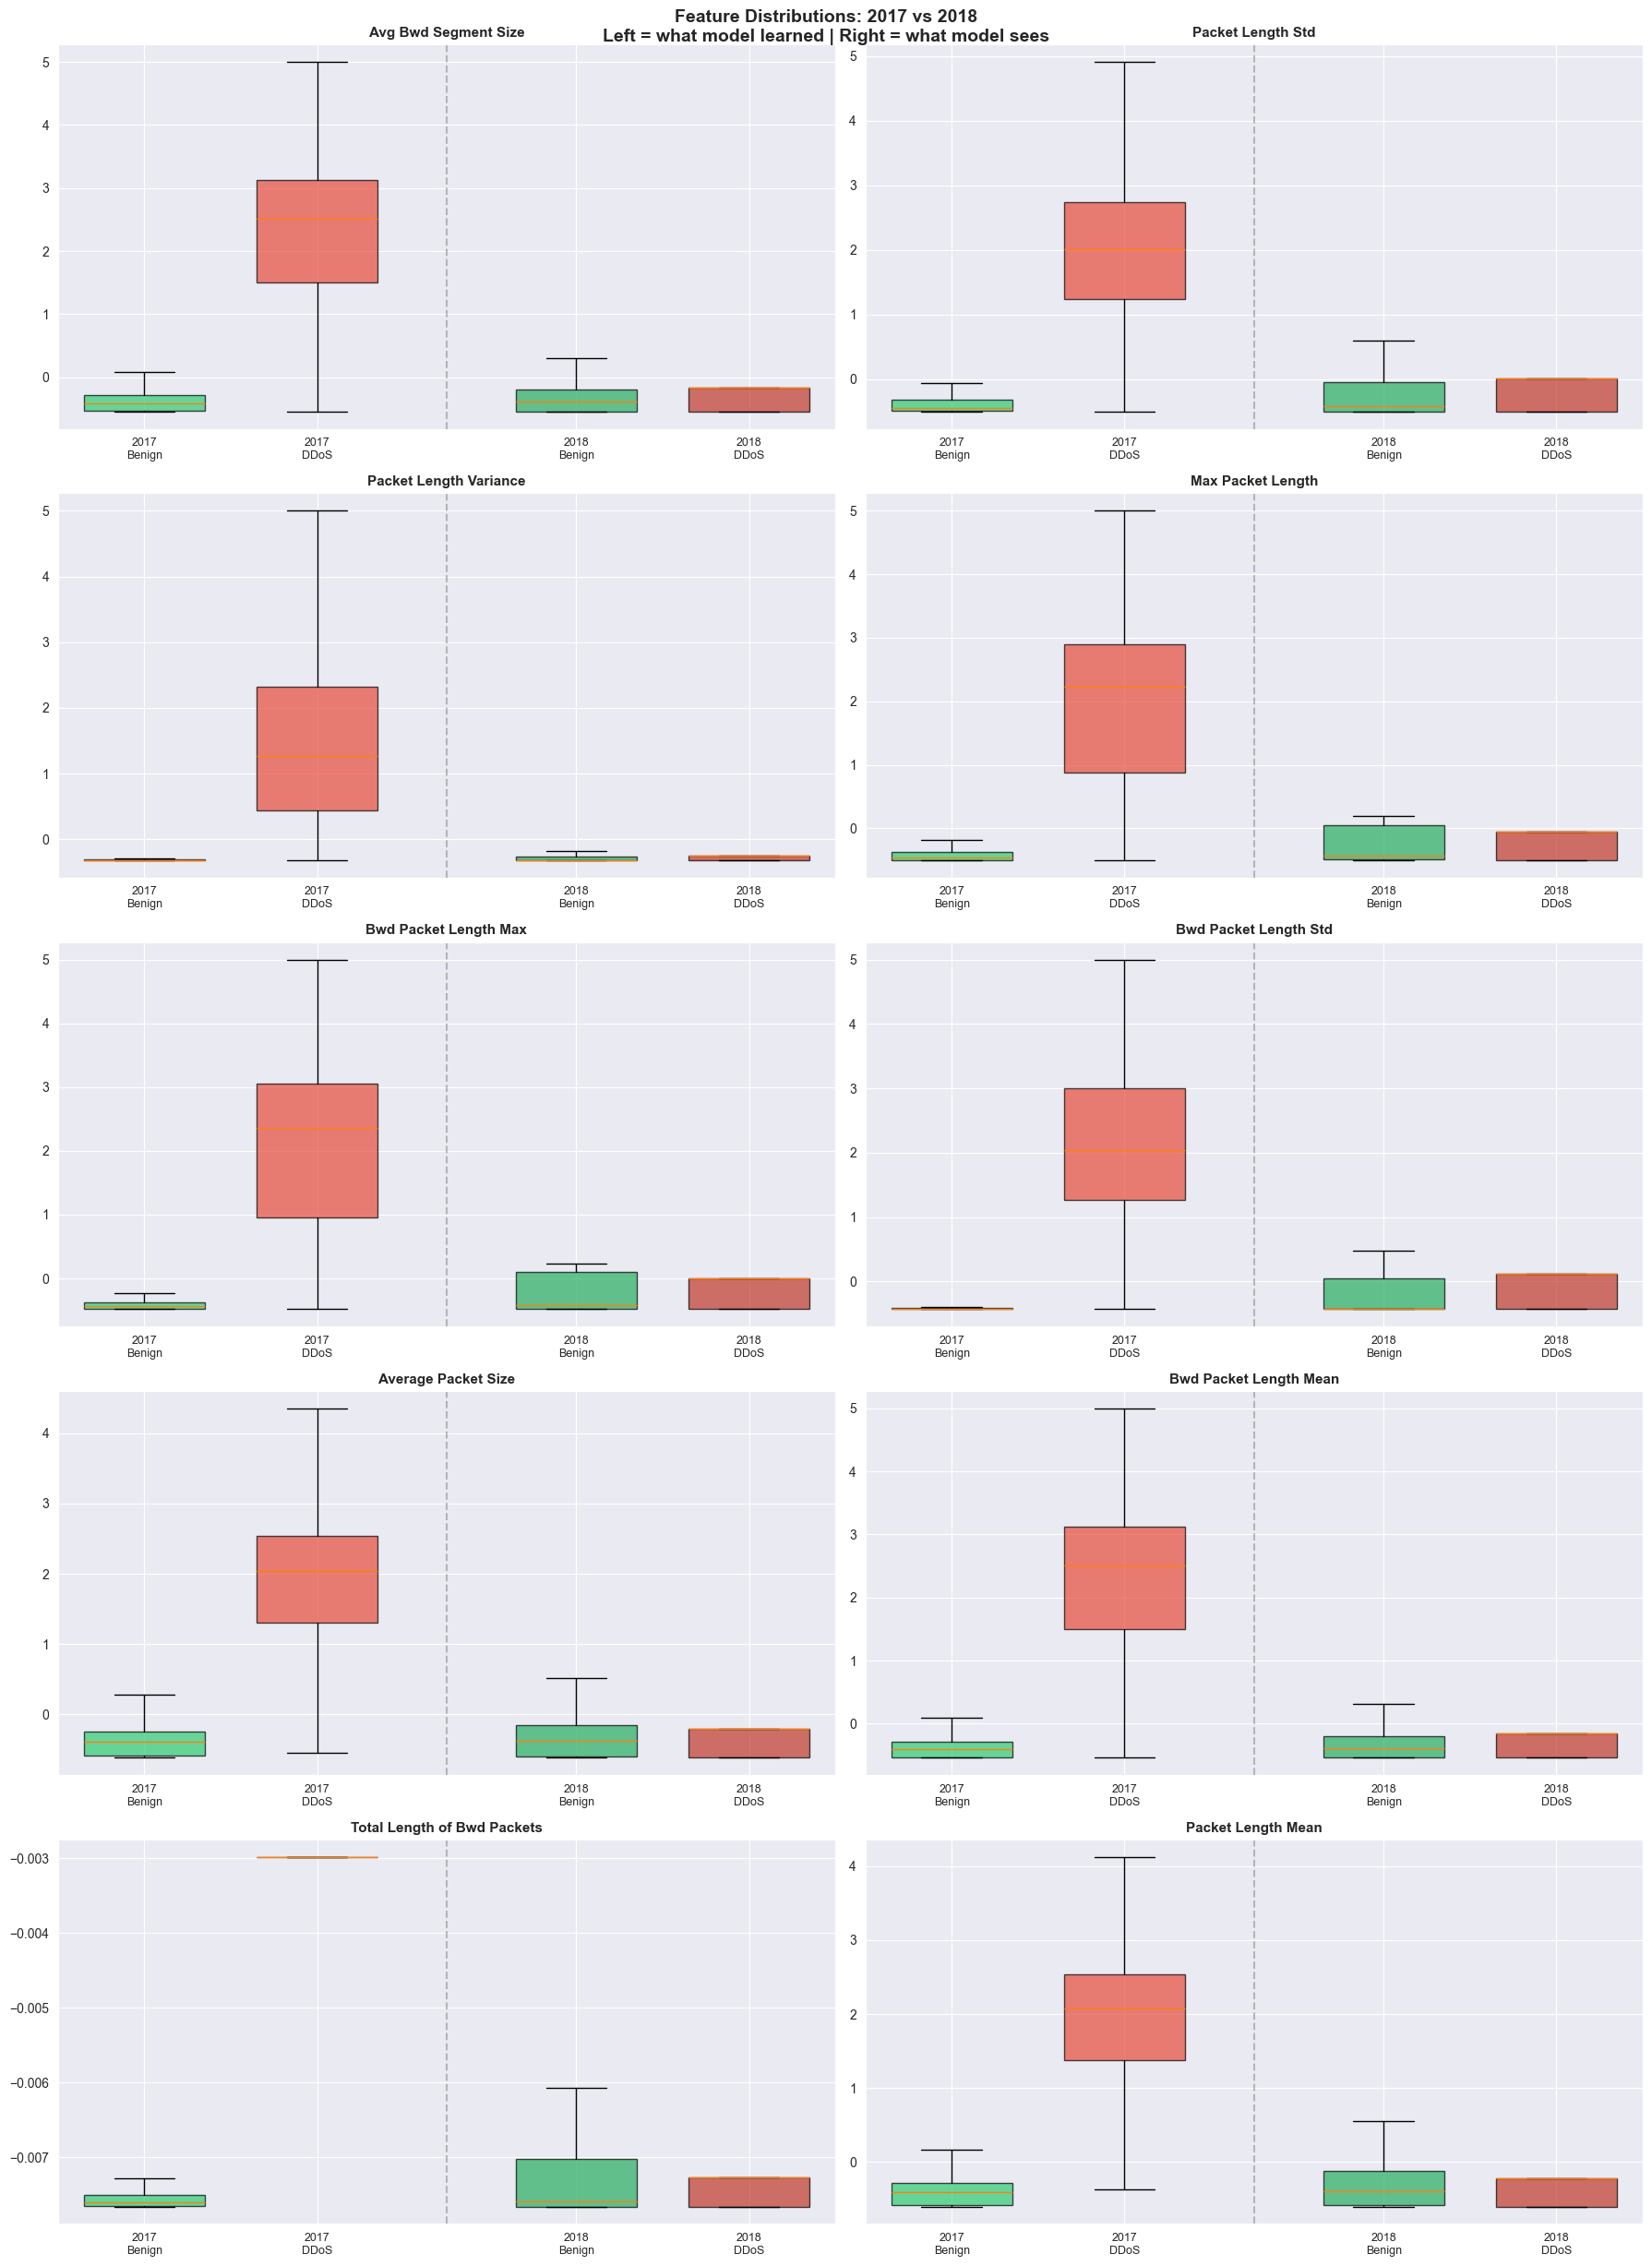

In [10]:
# For each top feature, compare:
# - What DDoS looks like in 2017 (what the model learned)
# - What DDoS looks like in 2018 (what the model sees at test time)
# - What Benign looks like in both (what the model compares against)

fig, axes = plt.subplots(5, 2, figsize=(18, 25))

for idx, feat in enumerate(top_10):
    ax = axes[idx // 2, idx % 2]

    data = {
        '2017 Benign': benign_2017[feat].clip(-5, 5),
        '2017 DDoS': ddos_2017[feat].clip(-5, 5),
        '2018 Benign': benign_2018_scaled[feat].clip(-5, 5),
        '2018 DDoS': ddos_2018_scaled[feat].clip(-5, 5),
    }

    colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']
    positions = [1, 2, 3.5, 4.5]

    bp = ax.boxplot(
        [data['2017 Benign'], data['2017 DDoS'], data['2018 Benign'], data['2018 DDoS']],
        positions=positions,
        widths=0.7,
        showfliers=False,
        patch_artist=True
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(['2017\nBenign', '2017\nDDoS', '2018\nBenign', '2018\nDDoS'], fontsize=9)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.axvline(x=2.75, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Feature Distributions: 2017 vs 2018\nLeft = what model learned | Right = what model sees',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Get model's prediction probabilities for 2018 DDoS traffic
ddos_2018_proba = rf.predict_proba(ddos_2018_scaled)
ddos_2018_preds = rf.predict(ddos_2018_scaled)

# What is the model classifying 2018 DDoS as?
pred_names = target_encoder.inverse_transform(ddos_2018_preds)
print("2018 DDoS traffic — model predictions:")
print(pd.Series(pred_names).value_counts())

# How confident is it?
ddos_class_idx = list(target_encoder.classes_).index('DoS/DDoS')
benign_class_idx = list(target_encoder.classes_).index('Benign')

print(f"\nModel confidence on 2018 DDoS samples:")
print(f"  Avg probability assigned to 'DoS/DDoS': {ddos_2018_proba[:, ddos_class_idx].mean():.4f}")
print(f"  Avg probability assigned to 'Benign':   {ddos_2018_proba[:, benign_class_idx].mean():.4f}")

# Compare with 2017 DDoS
ddos_2017_proba = rf.predict_proba(ddos_2017)
print(f"\nModel confidence on 2017 DDoS samples:")
print(f"  Avg probability assigned to 'DoS/DDoS': {ddos_2017_proba[:, ddos_class_idx].mean():.4f}")
print(f"  Avg probability assigned to 'Benign':   {ddos_2017_proba[:, benign_class_idx].mean():.4f}")

2018 DDoS traffic — model predictions:
Benign      575363
DoS/DDoS         1
Name: count, dtype: int64

Model confidence on 2018 DDoS samples:
  Avg probability assigned to 'DoS/DDoS': 0.1552
  Avg probability assigned to 'Benign':   0.8329

Model confidence on 2017 DDoS samples:
  Avg probability assigned to 'DoS/DDoS': 0.9983
  Avg probability assigned to 'Benign':   0.0016


In [12]:
# Direct comparison: median values of top features
comparison = pd.DataFrame({
    '2017_Benign': benign_2017[top_10].median(),
    '2017_DDoS': ddos_2017[top_10].median(),
    '2018_Benign': benign_2018_scaled[top_10].median(),
    '2018_DDoS': ddos_2018_scaled[top_10].median(),
})

comparison['2017_gap'] = comparison['2017_DDoS'] - comparison['2017_Benign']
comparison['2018_gap'] = comparison['2018_DDoS'] - comparison['2018_Benign']
comparison['shift'] = comparison['2018_DDoS'] - comparison['2017_DDoS']

print("Feature comparison (median scaled values):\n")
print(comparison.round(3).to_string())

print("\n\nKEY COLUMNS:")
print("  2017_gap = how different DDoS looks from Benign in 2017 (what model learned)")
print("  2018_gap = how different DDoS looks from Benign in 2018")
print("  shift    = how much DDoS features shifted between datasets")
print("             (large shift = model can't recognize the attack)")

Feature comparison (median scaled values):

                             2017_Benign  2017_DDoS  2018_Benign  2018_DDoS  2017_gap  2018_gap  shift
Avg Bwd Segment Size              -0.409      2.516       -0.382     -0.158     2.925     0.224 -2.674
Packet Length Std                 -0.454      2.004       -0.419      0.015     2.459     0.433 -1.990
Packet Length Variance            -0.314      1.263       -0.313     -0.248     1.577     0.065 -1.511
Max Packet Length                 -0.456      2.228       -0.436     -0.047     2.684     0.389 -2.276
Bwd Packet Length Max             -0.434      2.362       -0.413     -0.006     2.796     0.408 -2.368
Bwd Packet Length Std             -0.428      2.043       -0.428      0.119     2.471     0.547 -1.924
Average Packet Size               -0.391      2.038       -0.375     -0.208     2.428     0.167 -2.246
Bwd Packet Length Mean            -0.409      2.516       -0.382     -0.158     2.925     0.224 -2.674
Total Length of Bwd Packets  

In [13]:
# Let's check the features that SHOULD be attack-specific
# These describe behavior, not packet characteristics

behavioral_features = [
    'Flow Duration',
    'Flow Packets/s',
    'Flow Bytes/s',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'Flow IAT Mean',
    'Flow IAT Min',
    'Flow IAT Max',
    'Down/Up Ratio',
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count',
    'Total Fwd Packets',
    'Total Backward Packets',
]

# Only use features that exist in our model
behavioral_features = [f for f in behavioral_features if f in model_features]

comparison_behavioral = pd.DataFrame({
    '2017_Benign': benign_2017[behavioral_features].median(),
    '2017_DDoS': ddos_2017[behavioral_features].median(),
    '2018_Benign': benign_2018_scaled[behavioral_features].median(),
    '2018_DDoS': ddos_2018_scaled[behavioral_features].median(),
})
comparison_behavioral['2017_gap'] = comparison_behavioral['2017_DDoS'] - comparison_behavioral['2017_Benign']
comparison_behavioral['2018_gap'] = comparison_behavioral['2018_DDoS'] - comparison_behavioral['2018_Benign']
comparison_behavioral['shift'] = comparison_behavioral['2018_DDoS'] - comparison_behavioral['2017_DDoS']

print("BEHAVIORAL FEATURES (should be more stable):\n")
print(comparison_behavioral.round(3).to_string())

print("\n\nCOMPARISON:")
print(f"  Packet-size features avg shift:  {abs(comparison['shift']).mean():.3f}")
print(f"  Behavioral features avg shift:   {abs(comparison_behavioral['shift']).mean():.3f}")
print(f"\n  Lower shift = more stable across datasets = better for generalization")

BEHAVIORAL FEATURES (should be more stable):

                        2017_Benign  2017_DDoS  2018_Benign  2018_DDoS  2017_gap  2018_gap   shift
Flow Duration                -0.470      1.623       -0.462     -0.422     2.093     0.040  -2.045
Flow Packets/s               -0.233     -0.233       -0.233     -0.233    -0.000    -0.000   0.000
Flow Bytes/s                 -0.053     -0.053       -0.053     -0.053    -0.000    -0.000   0.000
Fwd Packets/s                -0.211     -0.211       -0.211     -0.211    -0.000    -0.000   0.000
Bwd Packets/s                -0.170     -0.171       -0.171     -0.171    -0.001    -0.000   0.000
Flow IAT Mean                -0.305      0.975       -0.293     -0.243     1.280     0.050  -1.218
Flow IAT Min                 -0.057     -0.057       -0.057     -0.057    -0.000    -0.000   0.000
Flow IAT Max                 -0.400      2.226       -0.393     -0.333     2.626     0.060  -2.560
Down/Up Ratio                 0.429     -1.002       -1.002    

In [14]:
# Let's find ALL features where 2018 DDoS looks different from 2018 Benign
# These are features that COULD detect 2018 DDoS if the model knew to look

all_comparison = pd.DataFrame({
    '2017_gap': (ddos_2017[model_features].median() - benign_2017[model_features].median()),
    '2018_gap': (ddos_2018_scaled[model_features].median() - benign_2018_scaled[model_features].median()),
})

all_comparison['gap_both'] = all_comparison['2017_gap'].abs() + all_comparison['2018_gap'].abs()
all_comparison['gap_2018_only'] = all_comparison['2018_gap'].abs()

# Features that discriminate DDoS in BOTH datasets (what we want)
print("=" * 70)
print("FEATURES THAT DETECT DDoS IN BOTH DATASETS (stable detectors):")
print("=" * 70)
both = all_comparison[
    (all_comparison['2017_gap'].abs() > 0.3) &
    (all_comparison['2018_gap'].abs() > 0.3)
].sort_values('gap_both', ascending=False)
print(both.round(3).to_string())

print(f"\n→ {len(both)} features detect DDoS in both datasets")

print("\n" + "=" * 70)
print("FEATURES THAT ONLY WORK IN 2017 (what our model relies on — useless):")
print("=" * 70)
only_2017 = all_comparison[
    (all_comparison['2017_gap'].abs() > 0.3) &
    (all_comparison['2018_gap'].abs() < 0.3)
].sort_values('2017_gap', ascending=False)
print(only_2017.round(3).head(15).to_string())

print(f"\n→ {len(only_2017)} features only work in 2017")

print("\n" + "=" * 70)
print("FEATURES THAT ONLY WORK IN 2018 (model doesn't know about these):")
print("=" * 70)
only_2018 = all_comparison[
    (all_comparison['2017_gap'].abs() < 0.3) &
    (all_comparison['2018_gap'].abs() > 0.3)
].sort_values('2018_gap', ascending=False)
print(only_2018.round(3).to_string())

print(f"\n→ {len(only_2018)} features only work in 2018")

FEATURES THAT DETECT DDoS IN BOTH DATASETS (stable detectors):
                       2017_gap  2018_gap  gap_both  gap_2018_only
Bwd Packet Length Max     2.796     0.408     3.204          0.408
Max Packet Length         2.684     0.389     3.074          0.389
Bwd Packet Length Std     2.471     0.547     3.018          0.547
Packet Length Std         2.459     0.433     2.892          0.433
Down/Up Ratio            -1.431     1.431     2.862          1.431

→ 5 features detect DDoS in both datasets

FEATURES THAT ONLY WORK IN 2017 (what our model relies on — useless):
                        2017_gap  2018_gap  gap_both  gap_2018_only
Bwd Packet Length Mean     2.925     0.224     3.150          0.224
Avg Bwd Segment Size       2.925     0.224     3.150          0.224
Idle Max                   2.634     0.000     2.634          0.000
Flow IAT Max               2.626     0.060     2.686          0.060
Fwd IAT Max                2.619    -0.006     2.625          0.006
Packet Length

In [15]:
# Find stable features for EVERY attack type, not just DDoS
# A "stable" feature has a meaningful gap between attack and benign
# in BOTH datasets

# Get all common attack types
common_attacks = ['Brute Force', 'DoS/DDoS', 'Infiltration']

# For each attack type, find which features discriminate it from benign
# in BOTH 2017 and 2018

stable_per_attack = {}

for attack in common_attacks:
    # 2017 samples
    attack_2017 = X_train_2017[y_train_names == attack]

    # 2018 samples
    attack_2018_raw = test_2018_sampled[test_2018_sampled['attack_category'] == attack][model_features]
    attack_2018_scaled = pd.DataFrame(
        scaler.transform(attack_2018_raw), columns=model_features
    )

    gaps = pd.DataFrame({
        '2017_gap': (attack_2017[model_features].median() - benign_2017[model_features].median()).abs(),
        '2018_gap': (attack_2018_scaled[model_features].median() - benign_2018_scaled[model_features].median()).abs(),
    })

    # Feature is stable if gap > 0.3 in BOTH datasets
    stable = gaps[(gaps['2017_gap'] > 0.3) & (gaps['2018_gap'] > 0.3)]
    stable_per_attack[attack] = set(stable.index)

    print(f"\n{attack}:")
    print(f"  Stable features: {len(stable)}")
    for feat in stable.index:
        print(f"    {feat:35s}  2017 gap: {gaps.loc[feat, '2017_gap']:.3f}  2018 gap: {gaps.loc[feat, '2018_gap']:.3f}")

# Features that work for ANY attack type
all_stable = set()
for attack, feats in stable_per_attack.items():
    all_stable = all_stable.union(feats)

print(f"\n{'='*60}")
print(f"TOTAL UNIQUE STABLE FEATURES: {len(all_stable)}")
print(f"{'='*60}")
for f in sorted(all_stable):
    attacks_using = [a for a, feats in stable_per_attack.items() if f in feats]
    print(f"  {f:35s} works for: {', '.join(attacks_using)}")

# Features that work for ALL attack types (most valuable)
universal = stable_per_attack[common_attacks[0]]
for attack in common_attacks[1:]:
    universal = universal.intersection(stable_per_attack[attack])

print(f"\nUNIVERSAL (work for ALL attacks): {len(universal)}")
for f in sorted(universal):
    print(f"  {f}")


Brute Force:
  Stable features: 2
    PSH Flag Count                       2017 gap: 2.187  2018 gap: 2.187
    Init_Win_bytes_forward               2017 gap: 1.990  2018 gap: 1.279

DoS/DDoS:
  Stable features: 5
    Bwd Packet Length Max                2017 gap: 2.796  2018 gap: 0.408
    Bwd Packet Length Std                2017 gap: 2.471  2018 gap: 0.547
    Max Packet Length                    2017 gap: 2.684  2018 gap: 0.389
    Packet Length Std                    2017 gap: 2.459  2018 gap: 0.433
    Down/Up Ratio                        2017 gap: 1.431  2018 gap: 1.431

Infiltration:
  Stable features: 0

TOTAL UNIQUE STABLE FEATURES: 7
  Bwd Packet Length Max               works for: DoS/DDoS
  Bwd Packet Length Std               works for: DoS/DDoS
  Down/Up Ratio                       works for: DoS/DDoS
  Init_Win_bytes_forward              works for: Brute Force
  Max Packet Length                   works for: DoS/DDoS
  PSH Flag Count                      works for: Brut

In [16]:
# PART 2: ENGINEER RATIO FEATURES
# These describe attack BEHAVIOR, not network CHARACTERISTICS
# Ratios are scale-invariant — they look the same on any network

# Reload raw unscaled data for both datasets
print("Engineering ratio features...\n")

# 2017 raw
df_2017_raw = pd.read_csv('../data/cicids2017_clean.csv', low_memory=False)
df_2017_raw.columns = df_2017_raw.columns.str.strip()

df_2017_raw['attack_category'] = df_2017_raw['Label'].apply(lambda x:
    'Benign' if x == 'BENIGN'
    else 'DoS/DDoS' if x in ['DoS Hulk', 'DoS GoldenEye', 'DoS slowloris', 'DoS Slowhttptest', 'DDoS', 'Heartbleed']
    else 'Brute Force' if x in ['FTP-Patator', 'SSH-Patator']
    else 'Web Attack' if 'Web Attack' in x
    else 'Reconnaissance' if x == 'PortScan'
    else 'Botnet' if x == 'Bot'
    else 'Infiltration' if x == 'Infiltration'
    else 'Unknown'
)

# 2018 raw (already have test_2018_sampled with original column names)
# Need raw unscaled values — reload from the sampled csv if you saved it
# Otherwise use the already loaded data before scaling

def engineer_features(df):
    """Create ratio features that are network-invariant"""
    features = pd.DataFrame()

    # 1. Packet direction ratio: what % of packets go forward?
    total_pkts = df['Total Fwd Packets'] + df['Total Backward Packets']
    features['fwd_pkt_ratio'] = df['Total Fwd Packets'] / total_pkts.replace(0, 1)

    # 2. Byte direction ratio: what % of bytes go forward?
    total_bytes = df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets']
    features['fwd_byte_ratio'] = df['Total Length of Fwd Packets'] / total_bytes.replace(0, 1)

    # 3. Packet size consistency: std / mean (high = varied sizes, low = uniform)
    features['pkt_size_cv'] = df['Packet Length Std'] / df['Packet Length Mean'].replace(0, 1)

    # 4. Fwd vs Bwd packet size ratio
    features['fwd_bwd_size_ratio'] = df['Fwd Packet Length Mean'] / df['Bwd Packet Length Mean'].replace(0, 1)

    # 5. Flow symmetry: are fwd and bwd packets balanced?
    features['flow_symmetry'] = df['Total Backward Packets'] / df['Total Fwd Packets'].replace(0, 1)

    # 6. Header to payload ratio (high = mostly headers = small packets = scanning)
    features['header_payload_ratio'] = df['Fwd Header Length'] / df['Total Length of Fwd Packets'].replace(0, 1)

    # 7. Flag ratios
    total_flags = (df['FIN Flag Count'] + df['SYN Flag Count'] + df['RST Flag Count'] +
                   df['PSH Flag Count'] + df['ACK Flag Count']).replace(0, 1)
    features['syn_ratio'] = df['SYN Flag Count'] / total_flags
    features['rst_ratio'] = df['RST Flag Count'] / total_flags
    features['psh_ratio'] = df['PSH Flag Count'] / total_flags
    features['fin_ratio'] = df['FIN Flag Count'] / total_flags
    features['ack_ratio'] = df['ACK Flag Count'] / total_flags

    # 8. IAT consistency: std / mean (high = irregular timing, low = automated)
    features['iat_cv'] = df['Flow IAT Std'] / df['Flow IAT Mean'].replace(0, 1)

    # 9. Bytes per packet (small = SYN flood, large = data transfer)
    features['bytes_per_fwd_pkt'] = df['Total Length of Fwd Packets'] / df['Total Fwd Packets'].replace(0, 1)
    features['bytes_per_bwd_pkt'] = df['Total Length of Bwd Packets'] / df['Total Backward Packets'].replace(0, 1)

    # 10. Subflow ratio
    features['subflow_fwd_ratio'] = df['Subflow Fwd Packets'] / total_pkts.replace(0, 1)

    # Clean infinities and NaN
    features = features.replace([np.inf, -np.inf], 0)
    features = features.fillna(0)

    return features

# Engineer features for 2017
eng_2017 = engineer_features(df_2017_raw)
eng_2017['attack_category'] = df_2017_raw['attack_category']

print(f"Engineered {eng_2017.shape[1] - 1} ratio features")
print(f"Features: {[c for c in eng_2017.columns if c != 'attack_category']}")

# Compare these ratio features across datasets
# First get 2018 raw values — need to undo the column mapping for test_2018_sampled
# Actually we need the raw unscaled 2018 data

print("\nNow checking if these ratios are stable across datasets...")

Engineering ratio features...

Engineered 15 ratio features
Features: ['fwd_pkt_ratio', 'fwd_byte_ratio', 'pkt_size_cv', 'fwd_bwd_size_ratio', 'flow_symmetry', 'header_payload_ratio', 'syn_ratio', 'rst_ratio', 'psh_ratio', 'fin_ratio', 'ack_ratio', 'iat_cv', 'bytes_per_fwd_pkt', 'bytes_per_bwd_pkt', 'subflow_fwd_ratio']

Now checking if these ratios are stable across datasets...


In [17]:
# PART 1: Lower threshold to 0.15 and recheck
print("RELAXED THRESHOLD (gap > 0.15 in both datasets):\n")

all_stable_relaxed = set()
stable_per_attack_relaxed = {}

for attack in common_attacks:
    attack_2017 = X_train_2017[y_train_names == attack]
    attack_2018_raw = test_2018_sampled[test_2018_sampled['attack_category'] == attack][model_features]
    attack_2018_scaled = pd.DataFrame(
        scaler.transform(attack_2018_raw), columns=model_features
    )

    gaps = pd.DataFrame({
        '2017_gap': (attack_2017[model_features].median() - benign_2017[model_features].median()).abs(),
        '2018_gap': (attack_2018_scaled[model_features].median() - benign_2018_scaled[model_features].median()).abs(),
    })

    stable = gaps[(gaps['2017_gap'] > 0.15) & (gaps['2018_gap'] > 0.15)]
    stable_per_attack_relaxed[attack] = set(stable.index)
    all_stable_relaxed = all_stable_relaxed.union(set(stable.index))

    print(f"{attack}: {len(stable)} stable features")

universal_relaxed = stable_per_attack_relaxed[common_attacks[0]]
for attack in common_attacks[1:]:
    universal_relaxed = universal_relaxed.intersection(stable_per_attack_relaxed[attack])

print(f"\nTotal unique stable features: {len(all_stable_relaxed)}")
print(f"Universal (all attacks): {len(universal_relaxed)}")
if universal_relaxed:
    for f in sorted(universal_relaxed):
        print(f"  {f}")

RELAXED THRESHOLD (gap > 0.15 in both datasets):

Brute Force: 2 stable features
DoS/DDoS: 9 stable features
Infiltration: 0 stable features

Total unique stable features: 11
Universal (all attacks): 0


In [18]:
# Engineer the same ratio features for 2018
# Need raw unscaled 2018 data — test_2018_sampled has original column names mapped to 2017 names

eng_2018 = engineer_features(test_2018_sampled)
eng_2018['attack_category'] = test_2018_sampled['attack_category'].values

# Now compare ratio features: DDoS, Brute Force across both datasets
ratio_features = [c for c in eng_2017.columns if c != 'attack_category']

print("RATIO FEATURE STABILITY ANALYSIS")
print("=" * 70)

for attack in ['DoS/DDoS', 'Brute Force', 'Infiltration']:
    benign_2017_eng = eng_2017[eng_2017['attack_category'] == 'Benign'][ratio_features]
    attack_2017_eng = eng_2017[eng_2017['attack_category'] == attack][ratio_features]

    if attack not in eng_2018['attack_category'].values:
        print(f"\n{attack}: not in 2018 data")
        continue

    benign_2018_eng = eng_2018[eng_2018['attack_category'] == 'Benign'][ratio_features]
    attack_2018_eng = eng_2018[eng_2018['attack_category'] == attack][ratio_features]

    comparison = pd.DataFrame({
        '2017_benign': benign_2017_eng.median(),
        '2017_attack': attack_2017_eng.median(),
        '2018_benign': benign_2018_eng.median(),
        '2018_attack': attack_2018_eng.median(),
    })
    comparison['2017_gap'] = (comparison['2017_attack'] - comparison['2017_benign']).abs()
    comparison['2018_gap'] = (comparison['2018_attack'] - comparison['2018_benign']).abs()
    comparison['shift'] = (comparison['2018_attack'] - comparison['2017_attack']).abs()

    # Stable = gap > 0.05 in both (lower threshold for ratios since they're 0-1 scale)
    stable = comparison[(comparison['2017_gap'] > 0.05) & (comparison['2018_gap'] > 0.05)]

    print(f"\n{attack}:")
    print(f"  Stable ratio features: {len(stable)} / {len(ratio_features)}")
    if len(stable) > 0:
        print(stable[['2017_gap', '2018_gap', 'shift']].sort_values('shift').round(4).to_string())

    # Show the best ones — low shift means consistent across datasets
    if len(stable) > 0:
        best = stable.sort_values('shift').head(3)
        print(f"\n  Best (lowest shift):")
        for feat in best.index:
            print(f"    {feat:25s} shift={best.loc[feat,'shift']:.4f}  "
                  f"2017: {comparison.loc[feat,'2017_attack']:.3f} vs {comparison.loc[feat,'2017_benign']:.3f}  "
                  f"2018: {comparison.loc[feat,'2018_attack']:.3f} vs {comparison.loc[feat,'2018_benign']:.3f}")

RATIO FEATURE STABILITY ANALYSIS

DoS/DDoS:
  Stable ratio features: 8 / 15
                       2017_gap  2018_gap      shift
fwd_bwd_size_ratio       0.3817    0.3764     0.0007
fwd_byte_ratio           0.2638    0.2597     0.0091
flow_symmetry            0.1429    0.4583     0.4762
iat_cv                   1.5180    1.1108     0.5292
pkt_size_cv              1.2866    1.7563     0.8892
header_payload_ratio     0.1874    3.3099     2.6897
bytes_per_fwd_pkt        1.8889   34.0893    29.4444
bytes_per_bwd_pkt     1848.9375  142.0000  1691.5000

  Best (lowest shift):
    fwd_bwd_size_ratio        shift=0.0007  2017: 0.027 vs 0.409  2018: 0.028 vs 0.404
    fwd_byte_ratio            shift=0.0091  2017: 0.029 vs 0.293  2018: 0.020 vs 0.280
    flow_symmetry             shift=0.4762  2017: 0.857 vs 1.000  2018: 1.333 vs 0.875

Brute Force:
  Stable ratio features: 9 / 15
                      2017_gap  2018_gap     shift
psh_ratio               1.0000    0.5000    0.0000
fwd_byte_ratio

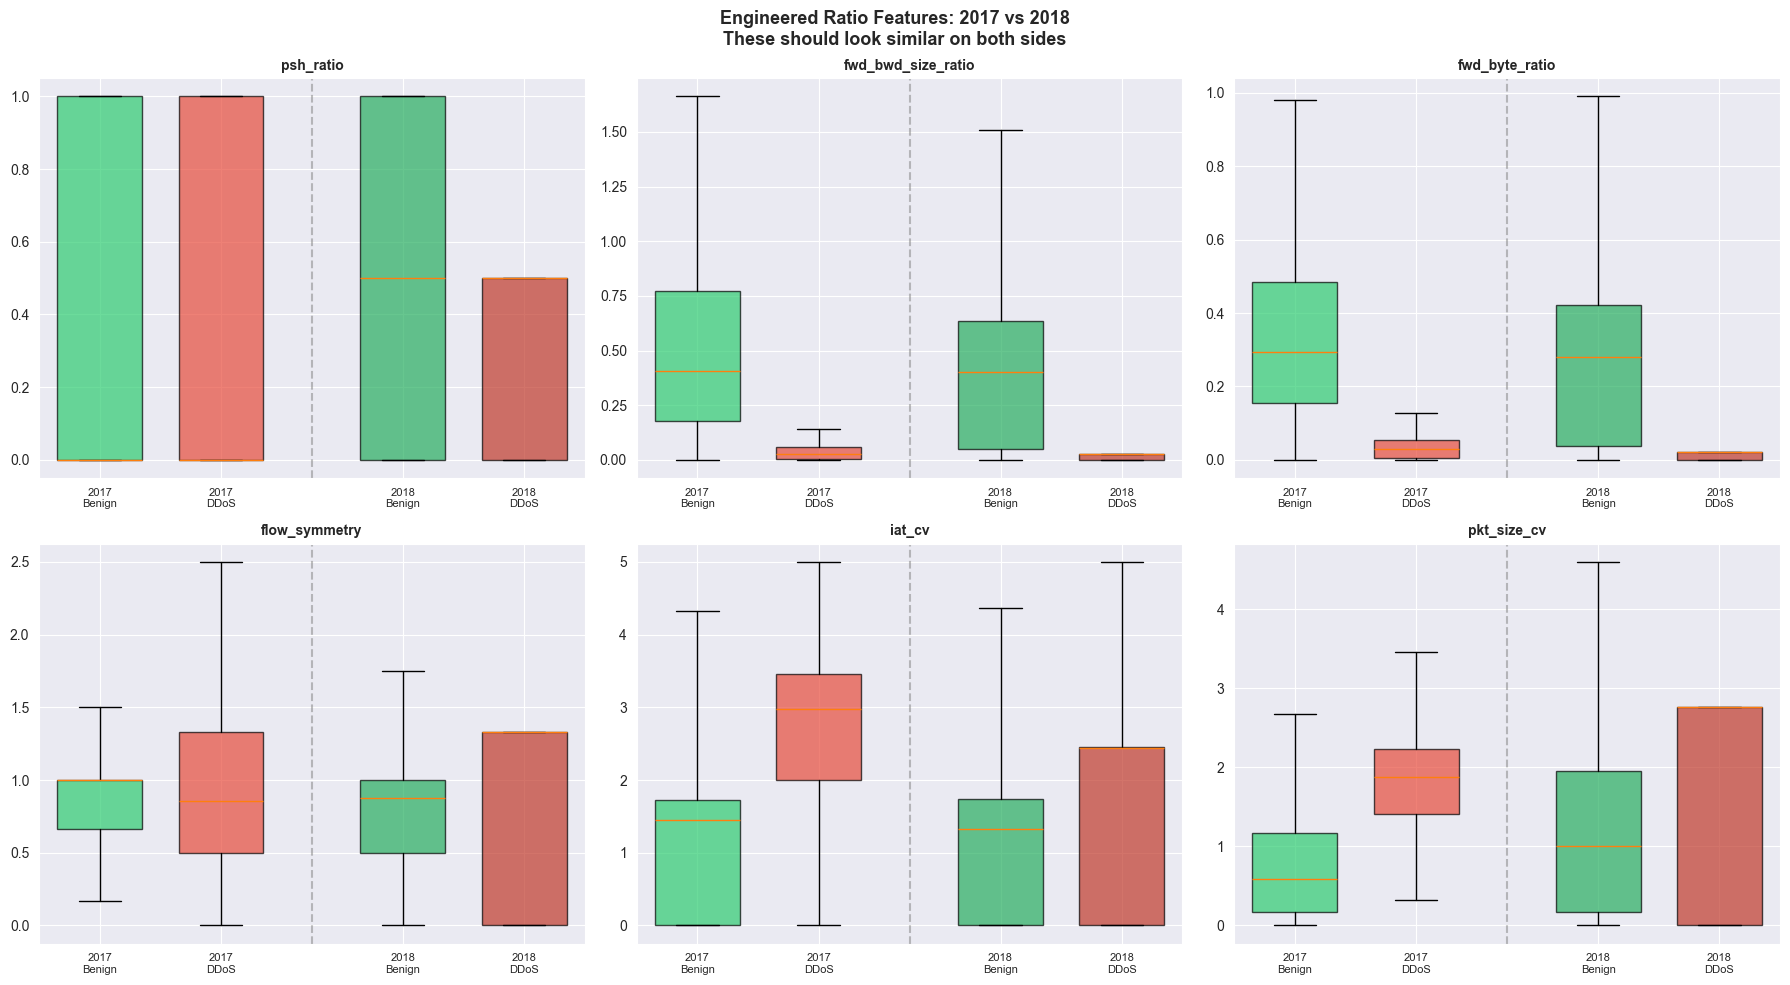

In [19]:
# Visualize the best ratio features
stable_ratios = []
for attack in ['DoS/DDoS', 'Brute Force']:
    benign_2017_eng = eng_2017[eng_2017['attack_category'] == 'Benign'][ratio_features]
    attack_2017_eng = eng_2017[eng_2017['attack_category'] == attack][ratio_features]
    benign_2018_eng = eng_2018[eng_2018['attack_category'] == 'Benign'][ratio_features]
    attack_2018_eng = eng_2018[eng_2018['attack_category'] == attack][ratio_features]

    for feat in ratio_features:
        gap_17 = abs(attack_2017_eng[feat].median() - benign_2017_eng[feat].median())
        gap_18 = abs(attack_2018_eng[feat].median() - benign_2018_eng[feat].median())
        shift = abs(attack_2018_eng[feat].median() - attack_2017_eng[feat].median())
        if gap_17 > 0.05 and gap_18 > 0.05:
            stable_ratios.append({
                'feature': feat, 'attack': attack,
                'gap_17': gap_17, 'gap_18': gap_18, 'shift': shift
            })

stable_df = pd.DataFrame(stable_ratios).drop_duplicates(subset='feature')
top_ratios = stable_df.sort_values('shift').head(6)['feature'].tolist()

if len(top_ratios) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    for idx, feat in enumerate(top_ratios[:6]):
        ax = axes[idx // 3, idx % 3]

        data = [
            eng_2017[eng_2017['attack_category'] == 'Benign'][feat].clip(-5, 5),
            eng_2017[eng_2017['attack_category'] == 'DoS/DDoS'][feat].clip(-5, 5),
            eng_2018[eng_2018['attack_category'] == 'Benign'][feat].clip(-5, 5),
            eng_2018[eng_2018['attack_category'] == 'DoS/DDoS'][feat].clip(-5, 5),
        ]

        bp = ax.boxplot(data, positions=[1, 2, 3.5, 4.5], widths=0.7,
                        showfliers=False, patch_artist=True)
        colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticks([1, 2, 3.5, 4.5])
        ax.set_xticklabels(['2017\nBenign', '2017\nDDoS', '2018\nBenign', '2018\nDDoS'], fontsize=8)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.axvline(x=2.75, color='gray', linestyle='--', alpha=0.5)

    plt.suptitle('Engineered Ratio Features: 2017 vs 2018\nThese should look similar on both sides',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No stable ratio features found — need to adjust approach")

In [20]:
# CROSS-DATASET MODEL USING RATIO FEATURES
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

# Select the most stable ratio features (stable for at least 2 attack types)
selected_ratios = [
    'fwd_byte_ratio',        # stable for all 3 attacks
    'fwd_bwd_size_ratio',    # near-zero shift for DDoS + Brute Force
    'iat_cv',                # stable for all 3
    'pkt_size_cv',           # stable for all 3
    'psh_ratio',             # zero shift for Brute Force
    'flow_symmetry',         # stable for DDoS + Brute Force
    'header_payload_ratio',  # stable for Infiltration
    'fwd_pkt_ratio',         # direction ratio — should be universal
    'syn_ratio',             # flag ratio
    'rst_ratio',             # flag ratio
    'ack_ratio',             # flag ratio
    'fin_ratio',             # flag ratio
]

print(f"Training with {len(selected_ratios)} engineered ratio features\n")

# Engineer for 2017
X_2017_ratios = eng_2017[selected_ratios]
y_2017_ratios = eng_2017['attack_category']

# Encode
y_2017_encoded = target_encoder.transform(y_2017_ratios)

# Split 2017
X_tr, X_te, y_tr, y_te = train_test_split(
    X_2017_ratios, y_2017_encoded,
    test_size=0.2, random_state=42, stratify=y_2017_encoded
)

# Scale
scaler_ratio = StandardScaler()
X_tr_scaled = scaler_ratio.fit_transform(X_tr)
X_te_scaled = scaler_ratio.transform(X_te)

# Train
rf_ratio = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_ratio.fit(X_tr_scaled, y_tr)

# Within-dataset test
y_within_pred = rf_ratio.predict(X_te_scaled)
class_names = target_encoder.classes_

print("=" * 60)
print("WITHIN-DATASET (ratio features) — CICIDS2017")
print("=" * 60)
print(classification_report(y_te, y_within_pred, target_names=class_names, zero_division=0))
within_f1 = f1_score(y_te, y_within_pred, average='macro', zero_division=0)

Training with 12 engineered ratio features

WITHIN-DATASET (ratio features) — CICIDS2017
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    419012
        Botnet       0.76      0.47      0.58       389
   Brute Force       1.00      0.96      0.98      1830
      DoS/DDoS       0.99      0.98      0.99     64354
  Infiltration       1.00      0.29      0.44         7
Reconnaissance       0.98      1.00      0.99     18139
    Web Attack       0.99      0.93      0.96       429

      accuracy                           0.99    504160
     macro avg       0.96      0.80      0.85    504160
  weighted avg       0.99      0.99      0.99    504160



In [21]:
# CROSS-DATASET TEST with ratio features
X_2018_ratios = eng_2018[selected_ratios]
y_2018_labels = eng_2018['attack_category']

# Only common classes
common = ['Benign', 'Brute Force', 'DoS/DDoS', 'Infiltration']
mask = y_2018_labels.isin(common)
X_2018_ratios = X_2018_ratios[mask]
y_2018_labels = y_2018_labels[mask]
y_2018_encoded = target_encoder.transform(y_2018_labels)

# Scale with 2017 scaler
X_2018_ratio_scaled = scaler_ratio.transform(X_2018_ratios)

# Predict
y_2018_pred = rf_ratio.predict(X_2018_ratio_scaled)

present_classes = sorted(y_2018_labels.unique())
present_indices = [list(class_names).index(c) for c in present_classes]

print("=" * 60)
print("CROSS-DATASET (ratio features) — 2017 model → 2018 data")
print("=" * 60)
print(classification_report(y_2018_encoded, y_2018_pred,
                            labels=present_indices,
                            target_names=present_classes, zero_division=0))

cross_f1 = f1_score(y_2018_encoded, y_2018_pred, labels=present_indices,
                     average='macro', zero_division=0)

print("=" * 60)
print("THE FULL COMPARISON")
print("=" * 60)
print(f"  78 raw features — within:    macro F1 = 0.910")
print(f"  78 raw features — cross:     macro F1 = 0.236")
print(f"  {len(selected_ratios)} ratio features — within:  macro F1 = {within_f1:.3f}")
print(f"  {len(selected_ratios)} ratio features — cross:   macro F1 = {cross_f1:.3f}")
print(f"")
print(f"  Cross-dataset improvement: {cross_f1 - 0.236:+.3f}")

CROSS-DATASET (ratio features) — 2017 model → 2018 data
              precision    recall  f1-score   support

      Benign       0.12      1.00      0.21    100000
 Brute Force       1.00      0.00      0.00     94101
    DoS/DDoS       0.00      0.00      0.00    575364
Infiltration       0.00      0.00      0.00     82531

   micro avg       0.12      0.12      0.12    851996
   macro avg       0.28      0.25      0.05    851996
weighted avg       0.12      0.12      0.02    851996

THE FULL COMPARISON
  78 raw features — within:    macro F1 = 0.910
  78 raw features — cross:     macro F1 = 0.236
  12 ratio features — within:  macro F1 = 0.847
  12 ratio features — cross:   macro F1 = 0.052

  Cross-dataset improvement: -0.184


In [22]:
# ATTEMPT 2: No scaling + combine ratio features with stable raw features
# Ratios are already normalized by design — scaling might hurt them

# Combine: 12 ratio features + 7 stable raw features from earlier analysis
stable_raw = [
    'Bwd Packet Length Max', 'Bwd Packet Length Std', 'Down/Up Ratio',
    'Init_Win_bytes_forward', 'Max Packet Length', 'PSH Flag Count',
    'Packet Length Std'
]

# Build combined features for 2017
combined_2017 = eng_2017[selected_ratios].copy()
for feat in stable_raw:
    combined_2017[feat] = df_2017_raw[feat].values

combined_2017['attack_category'] = eng_2017['attack_category'].values

# Build combined features for 2018
combined_2018 = eng_2018[selected_ratios].copy()
for feat in stable_raw:
    combined_2018[feat] = test_2018_sampled[feat].values

combined_2018['attack_category'] = eng_2018['attack_category'].values

feature_cols = selected_ratios + stable_raw
print(f"Combined feature set: {len(feature_cols)} features")
print(f"  Ratio features: {len(selected_ratios)}")
print(f"  Stable raw features: {len(stable_raw)}")

# Train on 2017 — NO SCALING for ratios, only scale raw features
X_combined = combined_2017[feature_cols]
y_combined = target_encoder.transform(combined_2017['attack_category'])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

# Clean infinities
X_tr = X_tr.replace([np.inf, -np.inf], 0).fillna(0)
X_te = X_te.replace([np.inf, -np.inf], 0).fillna(0)

# Train — Random Forest doesn't need scaling anyway
rf_combined = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_combined.fit(X_tr, y_tr)

# Within-dataset
y_within_pred = rf_combined.predict(X_te)
within_f1 = f1_score(y_te, y_within_pred, average='macro', zero_division=0)

print(f"\nWithin-dataset macro F1: {within_f1:.3f}")

# Cross-dataset on 2018
X_2018_combined = combined_2018[feature_cols]
y_2018_labels = combined_2018['attack_category']

common = ['Benign', 'Brute Force', 'DoS/DDoS', 'Infiltration']
mask = y_2018_labels.isin(common)
X_2018_combined = X_2018_combined[mask].replace([np.inf, -np.inf], 0).fillna(0)
y_2018_labels = y_2018_labels[mask]
y_2018_encoded = target_encoder.transform(y_2018_labels)

y_2018_pred = rf_combined.predict(X_2018_combined)

present_classes = sorted(y_2018_labels.unique())
present_indices = [list(class_names).index(c) for c in present_classes]

print("\n" + "=" * 60)
print("CROSS-DATASET (combined features, no scaling)")
print("=" * 60)
print(classification_report(y_2018_encoded, y_2018_pred,
                            labels=present_indices,
                            target_names=present_classes, zero_division=0))

cross_f1 = f1_score(y_2018_encoded, y_2018_pred, labels=present_indices,
                     average='macro', zero_division=0)

print("=" * 60)
print("FULL COMPARISON")
print("=" * 60)
print(f"  78 raw features — cross:             macro F1 = 0.236")
print(f"  12 ratios (scaled) — cross:          macro F1 = 0.052")
print(f"  19 combined (no scaling) — cross:    macro F1 = {cross_f1:.3f}")

Combined feature set: 19 features
  Ratio features: 12
  Stable raw features: 7

Within-dataset macro F1: 0.891

CROSS-DATASET (combined features, no scaling)
              precision    recall  f1-score   support

      Benign       0.12      1.00      0.21    100000
 Brute Force       0.00      0.00      0.00     94101
    DoS/DDoS       0.00      0.00      0.00    575364
Infiltration       0.00      0.00      0.00     82531

   micro avg       0.12      0.12      0.12    851996
   macro avg       0.03      0.25      0.05    851996
weighted avg       0.01      0.12      0.02    851996

FULL COMPARISON
  78 raw features — cross:             macro F1 = 0.236
  12 ratios (scaled) — cross:          macro F1 = 0.052
  19 combined (no scaling) — cross:    macro F1 = 0.052


In [23]:
# ANOMALY DETECTION APPROACH
# Instead of "what does a DDoS look like?"
# Ask "does this look like normal traffic?"
# Normal traffic is more consistent across networks than attacks

from sklearn.ensemble import IsolationForest

# Train on ONLY benign traffic from 2017
benign_2017_ratios = eng_2017[eng_2017['attack_category'] == 'Benign'][selected_ratios]
benign_2017_ratios = benign_2017_ratios.replace([np.inf, -np.inf], 0).fillna(0)

print(f"Training Isolation Forest on {len(benign_2017_ratios)} benign samples...")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # assume 5% of "benign" might be mislabeled
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(benign_2017_ratios)
print("Trained!")

# Test on 2017 first (within-dataset, binary: benign vs attack)
X_test_2017_ratios = eng_2017.sample(frac=0.2, random_state=42)
X_test_features = X_test_2017_ratios[selected_ratios].replace([np.inf, -np.inf], 0).fillna(0)
y_test_true = (X_test_2017_ratios['attack_category'] != 'Benign').astype(int)

# Isolation Forest: -1 = anomaly (attack), 1 = normal (benign)
y_test_iso = iso_forest.predict(X_test_features)
y_test_pred = (y_test_iso == -1).astype(int)  # convert to 0=benign, 1=attack

from sklearn.metrics import classification_report
print("\n" + "=" * 60)
print("WITHIN-DATASET — Isolation Forest (binary: benign vs attack)")
print("=" * 60)
print(classification_report(y_test_true, y_test_pred,
                            target_names=['Benign', 'Attack']))

Training Isolation Forest on 2095057 benign samples...
Trained!

WITHIN-DATASET — Isolation Forest (binary: benign vs attack)
              precision    recall  f1-score   support

      Benign       0.83      0.95      0.89    418898
      Attack       0.21      0.07      0.10     85262

    accuracy                           0.80    504160
   macro avg       0.52      0.51      0.49    504160
weighted avg       0.73      0.80      0.75    504160



In [24]:
# CROSS-DATASET — Isolation Forest on 2018
X_2018_iso = eng_2018[selected_ratios].replace([np.inf, -np.inf], 0).fillna(0)
y_2018_true = (eng_2018['attack_category'] != 'Benign').astype(int)

# Only common classes
common_mask = eng_2018['attack_category'].isin(['Benign', 'Brute Force', 'DoS/DDoS', 'Infiltration'])
X_2018_iso = X_2018_iso[common_mask]
y_2018_true = y_2018_true[common_mask]

y_2018_iso = iso_forest.predict(X_2018_iso)
y_2018_pred = (y_2018_iso == -1).astype(int)

print("=" * 60)
print("CROSS-DATASET — Isolation Forest (binary: benign vs attack)")
print("=" * 60)
print(classification_report(y_2018_true, y_2018_pred,
                            target_names=['Benign', 'Attack']))

# Per attack type breakdown
print("\nPer attack type detection rate:")
for attack in ['Benign', 'DoS/DDoS', 'Brute Force', 'Infiltration']:
    mask = eng_2018[common_mask]['attack_category'] == attack
    if mask.sum() > 0:
        preds = y_2018_pred[mask.values]
        if attack == 'Benign':
            correct = (preds == 0).mean()
            print(f"  {attack:20s}: {correct*100:.1f}% correctly identified as normal")
        else:
            detected = (preds == 1).mean()
            print(f"  {attack:20s}: {detected*100:.1f}% detected as attack")

print(f"\n{'='*60}")
print("COMPARISON (binary: benign vs attack)")
print(f"{'='*60}")
print(f"  Random Forest cross-dataset:     detected 0% of attacks")
print(f"  Isolation Forest cross-dataset:  see above")

CROSS-DATASET — Isolation Forest (binary: benign vs attack)
              precision    recall  f1-score   support

      Benign       0.12      0.98      0.21    100000
      Attack       0.70      0.01      0.01    751996

    accuracy                           0.12    851996
   macro avg       0.41      0.49      0.11    851996
weighted avg       0.63      0.12      0.04    851996


Per attack type detection rate:
  Benign              : 97.9% correctly identified as normal
  DoS/DDoS            : 0.1% detected as attack
  Brute Force         : 0.0% detected as attack
  Infiltration        : 5.3% detected as attack

COMPARISON (binary: benign vs attack)
  Random Forest cross-dataset:     detected 0% of attacks
  Isolation Forest cross-dataset:  see above
